#  Heart Disease Prediction using Machine Learning

## Project Overview

Cardiovascular diseases (CVDs) are one of the leading causes of death worldwide. According to the World Health Organization (WHO), nearly 17.9 million people die every year due to cardiovascular diseases, accounting for approximately 31% of all global deaths. Early diagnosis and timely treatment can significantly reduce mortality and improve patient outcomes.

Healthcare organizations collect large volumes of patient data containing demographic information, clinical test results, and medical history. By applying Machine Learning techniques to this data, hospitals can identify individuals at high risk of developing heart disease before severe complications occur.

In this project, we perform a comprehensive Exploratory Data Analysis (EDA), preprocess the data, build multiple Machine Learning classification models, compare their performance, and recommend the most suitable model for predicting heart disease. The insights generated from this analysis can help healthcare professionals make informed decisions and implement preventive healthcare strategies.

---

# Problem Statement

Develop a Machine Learning model capable of accurately predicting whether a patient is likely to have heart disease based on their medical attributes.

The project aims to assist healthcare professionals in identifying high-risk patients at an early stage, thereby enabling timely diagnosis, preventive care, and improved treatment planning.

---

# Business Objective

The primary objective of this project is to analyze patient health records and develop a predictive model that can accurately classify patients as either having heart disease or not.

The model should:

- Improve early detection of cardiovascular diseases.
- Support healthcare professionals in clinical decision-making.
- Reduce the risk of severe cardiac complications.
- Assist hospitals in prioritizing high-risk patients.
- Enable preventive healthcare through data-driven insights.

---

# Project Objectives

The major objectives of this project are:

- Understand the dataset and each medical feature.
- Perform comprehensive Exploratory Data Analysis (EDA).
- Identify patterns, trends, and relationships among variables.
- Clean and preprocess the dataset.
- Handle missing values, duplicates, and outliers appropriately.
- Encode categorical variables where necessary.
- Build multiple Machine Learning classification models.
- Evaluate and compare model performance using suitable metrics.
- Select the best-performing model for deployment.
- Provide business insights and recommendations for healthcare professionals.

---

# Domain

Healthcare

---

# Machine Learning Problem Type

Binary Classification

Target Variable:
- target
    - 0 → No Heart Disease
    - 1 → Heart Disease

---

# Project Workflow

1. Business Understanding
2. Data Collection
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Data Preprocessing
8. Model Building
9. Hyperparameter Tuning
10. Model Evaluation
11. Model Comparison
12. Business Insights
13. Hospital Recommendations
14. Conclusion

# Import Required Libraries

## Objective

Before starting the data analysis, we import all the required Python libraries for data manipulation, visualization, preprocessing, model building, and performance evaluation.

Each library has a specific purpose:

- **NumPy**: Numerical computations and array operations.
- **Pandas**: Data loading, cleaning, and manipulation.
- **Matplotlib**: Basic data visualization.
- **Seaborn**: Advanced statistical visualizations.
- **Warnings**: Suppress unnecessary warning messages.
- **Scikit-learn**: Machine Learning algorithms, preprocessing, model evaluation, and hyperparameter tuning.

Importing only the necessary libraries helps improve code readability, maintainability, and execution efficiency.

In [1]:
# Import Required Libraries

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Plot Settings
plt.style.use("default")
sns.set_theme(style="whitegrid", palette="Set2")

# Machine Learning - Data Preprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display library versions
print("=" * 50)
print("Library Versions")
print("=" * 50)
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Matplotlib : {plt.matplotlib.__version__}")
print(f"Seaborn    : {sns.__version__}")

Library Versions
NumPy      : 2.3.5
Pandas     : 2.3.3
Matplotlib : 3.10.0
Seaborn    : 0.13.2


# Project Configuration and Dataset Loading

## Objective

Before performing any analysis, it is important to configure the project environment and load the dataset correctly.

This step includes:

- Setting a random seed to ensure reproducibility.
- Defining the dataset file path.
- Loading the dataset into a Pandas DataFrame.
- Displaying the dataset dimensions.
- Previewing the first few records.
- Verifying that the dataset has been loaded successfully.

Using a structured configuration at the beginning of the project improves code organization, reproducibility, and maintainability.


The dataset for this project is provided in two separate files:

- **Values Dataset**: Contains all patient features.
- **Labels Dataset**: Contains the target variable indicating the presence of heart disease.

Since both files share the same unique patient identifier (`patient_id`), they will be merged into a single DataFrame before proceeding with data analysis and machine learning.

Merging the datasets ensures that each patient's medical information is correctly associated with the corresponding target label.

In [2]:
# Project Configuration

RANDOM_STATE = 42

# File Paths
VALUES_PATH = "values.csv"
LABELS_PATH = "labels.csv"

print("=" * 60)
print("Project Configuration")
print("=" * 60)
print(f"Values Dataset : {VALUES_PATH}")
print(f"Labels Dataset : {LABELS_PATH}")

Project Configuration
Values Dataset : values.csv
Labels Dataset : labels.csv


In [3]:
# Load Datasets

values_df = pd.read_csv(VALUES_PATH)
labels_df = pd.read_csv(LABELS_PATH)

print("Values Dataset Shape :", values_df.shape)
print("Labels Dataset Shape :", labels_df.shape)

Values Dataset Shape : (180, 14)
Labels Dataset Shape : (180, 2)


In [4]:
print("Values Dataset")
display(values_df.head())

print("\nLabels Dataset")
display(labels_df.head())

Values Dataset


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.00,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.60,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.00,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.00,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.20,1,59,145,0



Labels Dataset


,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [5]:
# Merge Values and Labels

df = pd.merge(
    values_df,
    labels_df,
    on="patient_id",
    how="inner"
)

print("=" * 60)
print("Datasets Merged Successfully")
print("=" * 60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Datasets Merged Successfully
Rows    : 180
Columns : 15


In [6]:
display(df.head())

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.00,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.60,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.00,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.00,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.20,1,59,145,0,0


In [7]:
print("Shape :", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nDataset Information\n")
df.info()

Shape : (180, 15)

Column Names:

['patient_id', 'slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina', 'heart_disease_present']

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels       

# Dataset Understanding

## Objective

Understanding the dataset is an essential step before performing any data preprocessing or exploratory data analysis.

In this section, we will:

- Examine the structure of the dataset.
- Understand each feature and its data type.
- Identify numerical, categorical, binary, and identifier variables.
- Generate descriptive statistics.
- Count unique values.
- Detect missing values.
- Detect duplicate records.
- Understand the target variable.

A comprehensive understanding of the dataset helps in selecting appropriate preprocessing techniques and building more accurate machine learning models.

In [8]:
# Dataset Shape

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Dataset Shape
Number of Rows    : 180
Number of Columns : 15


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [10]:
# Data Types

datatype_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

display(datatype_df)

,Feature,Data Type
0,patient_id,object
1,slope_of_peak_exercise_st_segment,int64
2,thal,object
3,resting_blood_pressure,int64
4,chest_pain_type,int64
5,num_major_vessels,int64
6,fasting_blood_sugar_gt_120_mg_per_dl,int64
7,resting_ekg_results,int64
8,serum_cholesterol_mg_per_dl,int64
9,oldpeak_eq_st_depression,float64


In [11]:
# Statistical Summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
slope_of_peak_exercise_st_segment,180.00,1.55,0.62,1.00,1.00,1.00,2.00,3.00
resting_blood_pressure,180.00,131.31,17.01,94.00,120.00,130.00,140.00,180.00
chest_pain_type,180.00,3.16,0.94,1.00,3.00,3.00,4.00,4.00
num_major_vessels,180.00,0.69,0.97,0.00,0.00,0.00,1.00,3.00
fasting_blood_sugar_gt_120_mg_per_dl,180.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
resting_ekg_results,180.00,1.05,1.00,0.00,0.00,2.00,2.00,2.00
serum_cholesterol_mg_per_dl,180.00,249.21,52.72,126.00,213.75,245.50,281.25,564.00
oldpeak_eq_st_depression,180.00,1.01,1.12,0.00,0.00,0.80,1.60,6.20
sex,180.00,0.69,0.46,0.00,0.00,1.00,1.00,1.00
age,180.00,54.81,9.33,29.00,48.00,55.00,62.00,77.00


In [12]:
# Missing Values

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_df)

,Missing Values,Percentage
patient_id,0,0.00
slope_of_peak_exercise_st_segment,0,0.00
thal,0,0.00
resting_blood_pressure,0,0.00
chest_pain_type,0,0.00
num_major_vessels,0,0.00
fasting_blood_sugar_gt_120_mg_per_dl,0,0.00
resting_ekg_results,0,0.00
serum_cholesterol_mg_per_dl,0,0.00
oldpeak_eq_st_depression,0,0.00


In [13]:
# Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [14]:
# Unique Values

unique_df = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

display(unique_df)

,Feature,Unique Values
0,patient_id,180
1,slope_of_peak_exercise_st_segment,3
2,thal,3
3,resting_blood_pressure,36
4,chest_pain_type,4
5,num_major_vessels,4
6,fasting_blood_sugar_gt_120_mg_per_dl,2
7,resting_ekg_results,3
8,serum_cholesterol_mg_per_dl,118
9,oldpeak_eq_st_depression,34


In [15]:
# Feature Classification

identifier_features = ["patient_id"]

target_feature = ["heart_disease_present"]

categorical_features = [
    "thal"
]

binary_features = [
    "sex",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "exercise_induced_angina",
    "heart_disease_present"
]

numerical_features = [
    column
    for column in df.columns
    if column not in identifier_features
    and column not in categorical_features
    and column not in binary_features
]

print("Identifier Feature")
print(identifier_features)

print("\nCategorical Feature")
print(categorical_features)

print("\nBinary Features")
print(binary_features)

print("\nNumerical Features")
print(numerical_features)

print("\nTarget Feature")
print(target_feature)

Identifier Feature
['patient_id']

Categorical Feature
['thal']

Binary Features
['sex', 'fasting_blood_sugar_gt_120_mg_per_dl', 'exercise_induced_angina', 'heart_disease_present']

Numerical Features
['slope_of_peak_exercise_st_segment', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'age', 'max_heart_rate_achieved']

Target Feature
['heart_disease_present']


# Initial Observations

After performing the initial inspection of the dataset, the following observations can be made:

- The merged dataset contains **180 patient records**.
- The dataset consists of **15 variables**, including one target variable.
- `patient_id` is a unique identifier and will not be used for model training.
- The target variable is **heart_disease_present**, indicating whether a patient has heart disease.
- Both numerical and categorical features are present in the dataset.
- The dataset will be further examined for missing values, outliers, feature distributions, and relationships among variables during the Exploratory Data Analysis phase.

# Data Cleaning and Data Quality Assessment

## Objective

Data cleaning is a critical step in every data science project. The quality of the input data directly impacts the performance and reliability of machine learning models.

In this section, we will:

- Create a working copy of the original dataset.
- Verify missing values.
- Check for duplicate records.
- Validate data types.
- Inspect categorical values for consistency.
- Identify invalid or impossible values.
- Remove unnecessary features for modeling.
- Prepare a clean dataset for Exploratory Data Analysis (EDA).

Although this dataset is relatively clean, performing these validation steps ensures data integrity and follows industry best practices.

In [16]:
# Create a Working Copy

eda_df = df.copy()

print("Working copy created successfully.")
print(f"Shape: {eda_df.shape}")

Working copy created successfully.
Shape: (180, 15)


In [17]:
# Missing Value Analysis

missing_values = eda_df.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(eda_df) * 100).round(2)
})

display(missing_summary)

,Missing Values,Percentage (%)
patient_id,0,0.00
slope_of_peak_exercise_st_segment,0,0.00
thal,0,0.00
resting_blood_pressure,0,0.00
chest_pain_type,0,0.00
num_major_vessels,0,0.00
fasting_blood_sugar_gt_120_mg_per_dl,0,0.00
resting_ekg_results,0,0.00
serum_cholesterol_mg_per_dl,0,0.00
oldpeak_eq_st_depression,0,0.00


In [18]:
# Duplicate Records

duplicate_count = eda_df.duplicated().sum()
print(f"Duplicate Records: {duplicate_count}")
if duplicate_count > 0:
    eda_df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

Duplicate Records: 0
No duplicate records found.


In [19]:
# Verify Data Types

display(eda_df.dtypes.to_frame(name="Data Type"))

,Data Type
patient_id,object
slope_of_peak_exercise_st_segment,int64
thal,object
resting_blood_pressure,int64
chest_pain_type,int64
num_major_vessels,int64
fasting_blood_sugar_gt_120_mg_per_dl,int64
resting_ekg_results,int64
serum_cholesterol_mg_per_dl,int64
oldpeak_eq_st_depression,float64


In [20]:
# Unique Categories

categorical_columns = ["thal"]

for column in categorical_columns:
    print("=" * 50)
    print(f"{column}")
    print("=" * 50)
    print(eda_df[column].value_counts(dropna=False))
    print()

thal
thal
normal               98
reversible_defect    74
fixed_defect          8
Name: count, dtype: int64



In [21]:
# Binary Feature Validation

binary_columns = [
    "sex",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "exercise_induced_angina",
    "heart_disease_present"
]

for column in binary_columns:
    print("=" * 50)
    print(column)
    print("=" * 50)
    print(sorted(eda_df[column].unique()))
    print()

sex
[np.int64(0), np.int64(1)]

fasting_blood_sugar_gt_120_mg_per_dl
[np.int64(0), np.int64(1)]

exercise_induced_angina
[np.int64(0), np.int64(1)]

heart_disease_present
[np.int64(0), np.int64(1)]



In [22]:
# Remove Identifier Column

eda_df.drop(columns=["patient_id"], inplace=True)
print("patient_id column removed successfully.")
print(f"Updated Shape: {eda_df.shape}")

patient_id column removed successfully.
Updated Shape: (180, 14)


In [23]:
# Final Dataset Check

display(eda_df.head())
print("\nDataset Shape:", eda_df.shape)

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.00,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.60,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.00,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.00,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.20,1,59,145,0,0



Dataset Shape: (180, 14)


# Data Cleaning Summary

The following data quality checks were performed:

- A working copy of the dataset was created.
- Missing values were inspected.
- Duplicate records were checked and removed if present.
- Data types were verified.
- Categorical values were validated for consistency.
- Binary features were checked to ensure valid values.
- The `patient_id` column was removed because it is a unique identifier and does not contribute to predictive modeling.

The dataset is now clean, validated, and ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, discover hidden patterns, identify relationships among variables, detect anomalies, and generate meaningful business insights.

In this section, we will:

- Analyze the distribution of the target variable.
- Study numerical and categorical features.
- Detect outliers.
- Examine relationships between variables.
- Identify important factors influencing heart disease.

The insights obtained during EDA will guide feature selection and help improve the performance of machine learning models.

# Target Variable Analysis

## Objective

The target variable represents whether a patient has heart disease.

Understanding the class distribution is important because:

- It reveals whether the dataset is balanced or imbalanced.
- It helps in selecting appropriate evaluation metrics.
- It determines whether resampling techniques may be required during model building.

The target variable is:

- **0 → No Heart Disease**
- **1 → Heart Disease**

In [24]:
# Target Variable Distribution

target_counts = eda_df["heart_disease_present"].value_counts().sort_index()
display(target_counts)

heart_disease_present
0    100
1     80
Name: count, dtype: int64

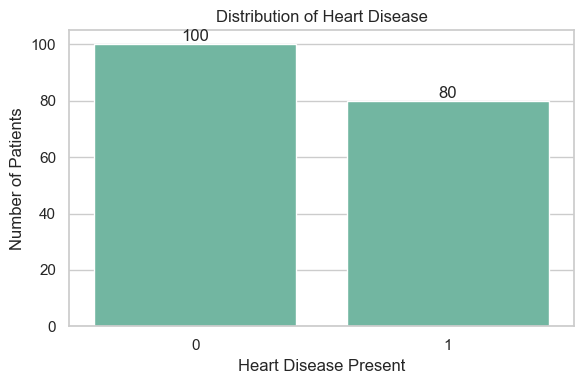

In [25]:
# Target Count Plot

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=eda_df,
    x="heart_disease_present"
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [26]:
# Percentage Distribution

target_percentage = (
    eda_df["heart_disease_present"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(target_percentage)

heart_disease_present
0   55.56
1   44.44
Name: proportion, dtype: float64

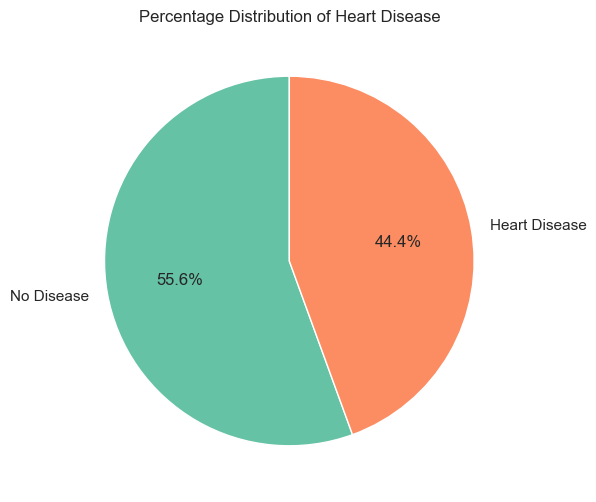

In [27]:
# Pie Chart

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["No Disease","Heart Disease"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Heart Disease")

plt.show()

# Interpretation

### Observations

- The target variable consists of two classes.
- The distribution of patients with and without heart disease is visually examined.
- A balanced dataset generally helps machine learning algorithms learn equally from both classes.
- If the dataset is imbalanced, additional techniques such as class weighting or resampling may be considered during model building.

### Business Insight

Understanding the prevalence of heart disease within the dataset helps hospitals estimate the proportion of high-risk patients and supports effective healthcare resource planning.

# Univariate Analysis of Numerical Features

## Objective

Numerical variables provide valuable information regarding patient health characteristics.

The objective of this analysis is to:

- Understand the distribution of each numerical variable.
- Identify skewness.
- Detect unusual observations.
- Observe the spread of the data.

Histograms with Kernel Density Estimation (KDE) curves are used to visualize the distributions.

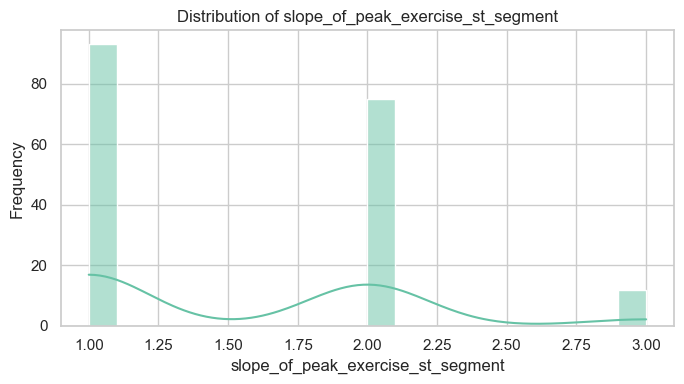

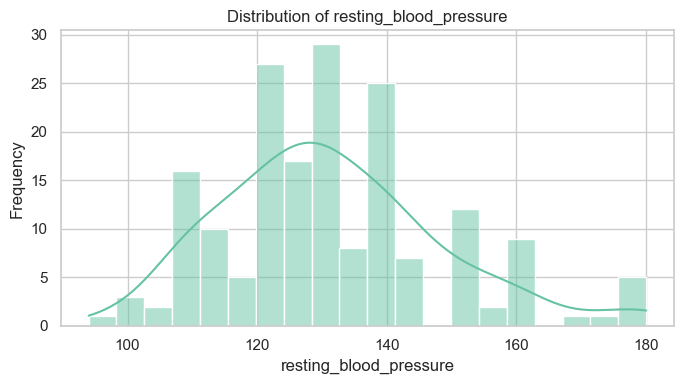

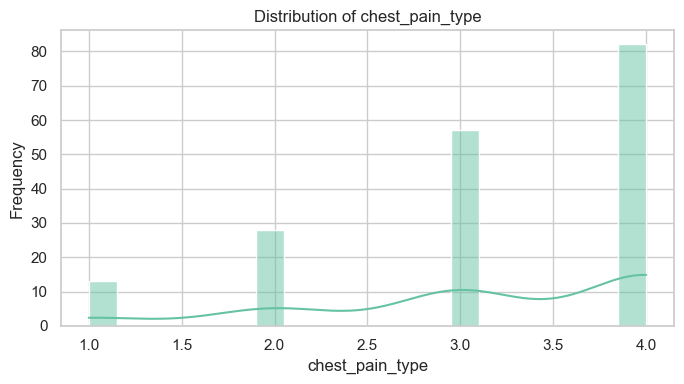

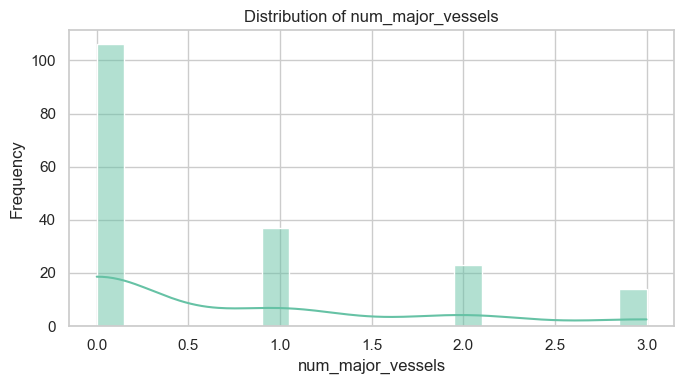

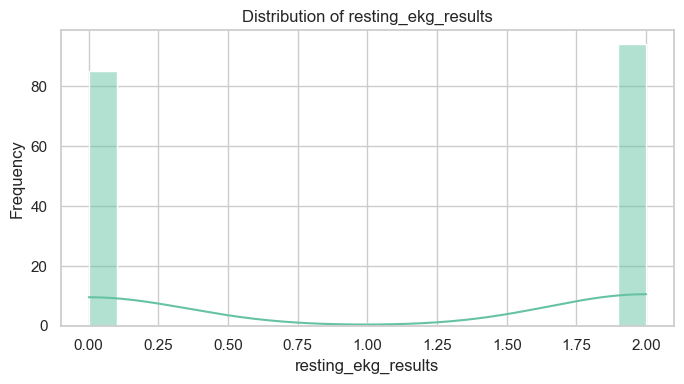

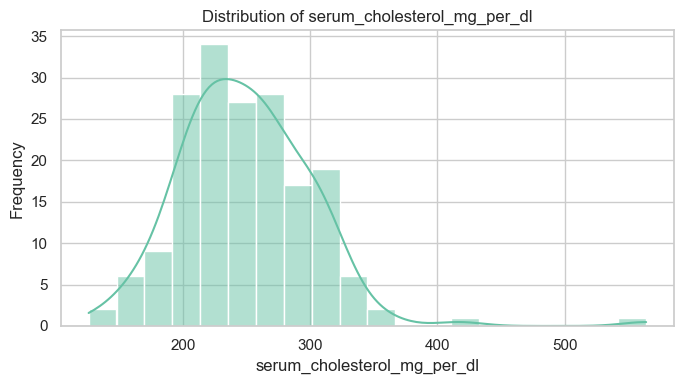

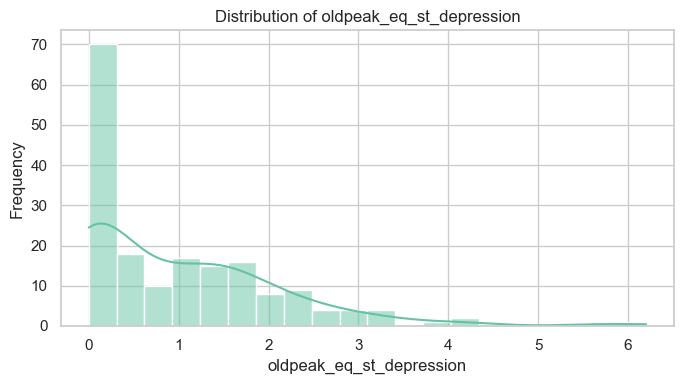

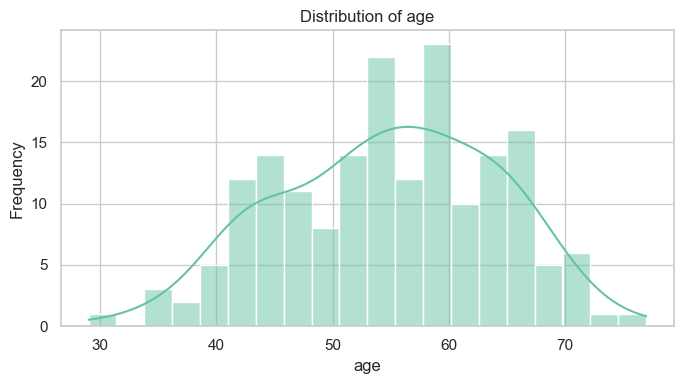

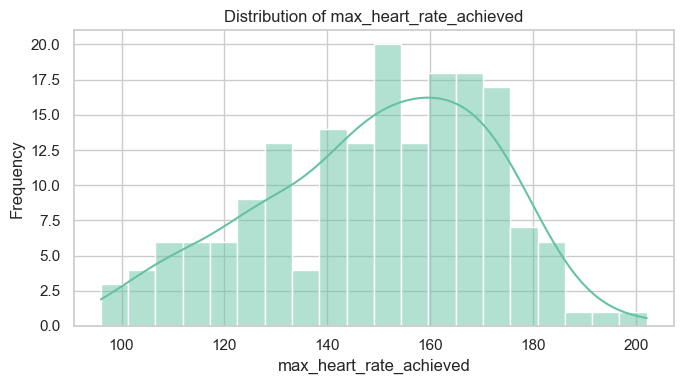

In [28]:
# Numerical Feature Distribution

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=eda_df,
        x=feature,
        kde=True,
        bins=20
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Outlier Analysis

## Objective

Outliers are observations that lie significantly outside the normal range of the data. In healthcare datasets, outliers may represent measurement errors, data entry mistakes, or genuine high-risk patients.

The objective of this analysis is to:

- Identify the presence of outliers in numerical variables.
- Understand the spread of each feature.
- Determine whether outliers require treatment before model building.

Boxplots are used because they effectively visualize the median, quartiles, and potential outliers.

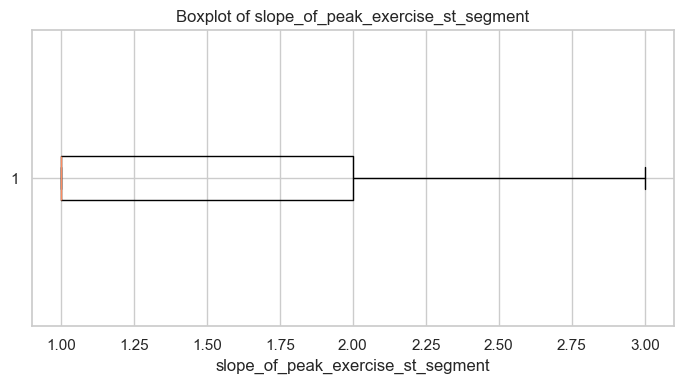

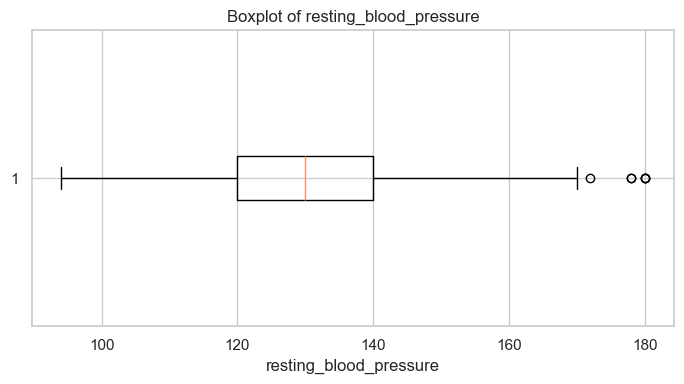

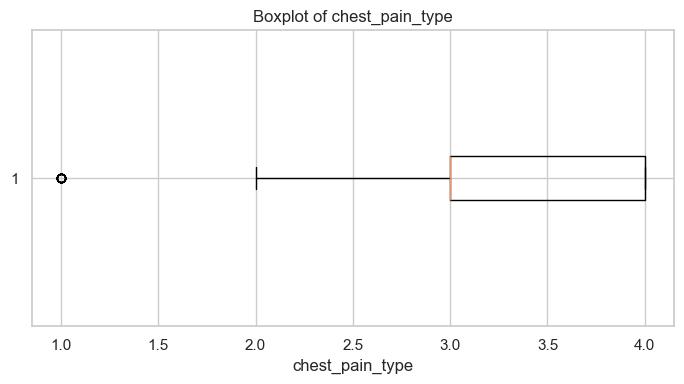

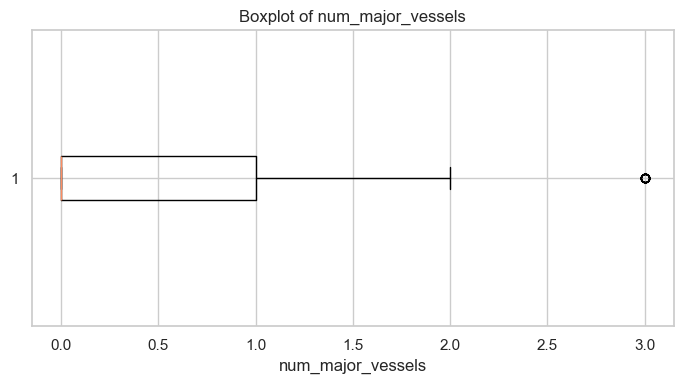

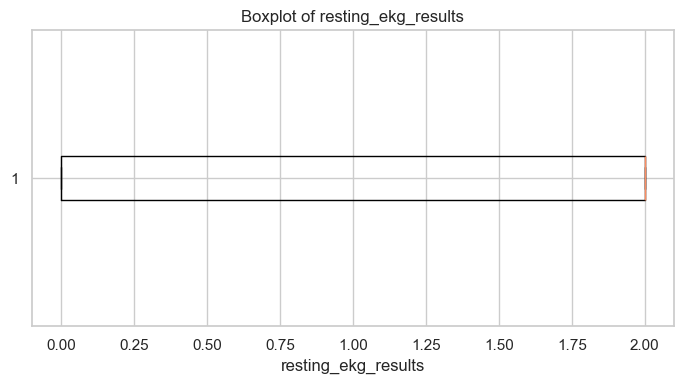

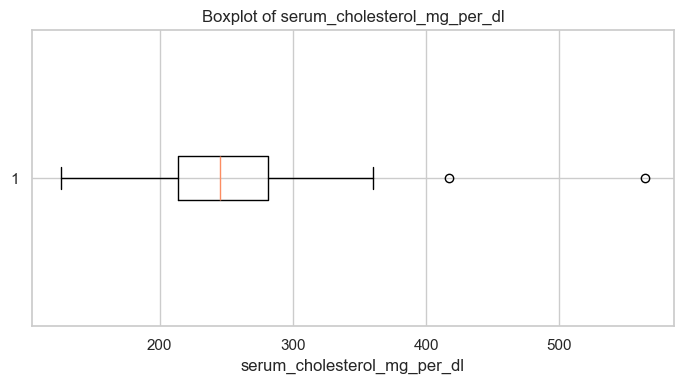

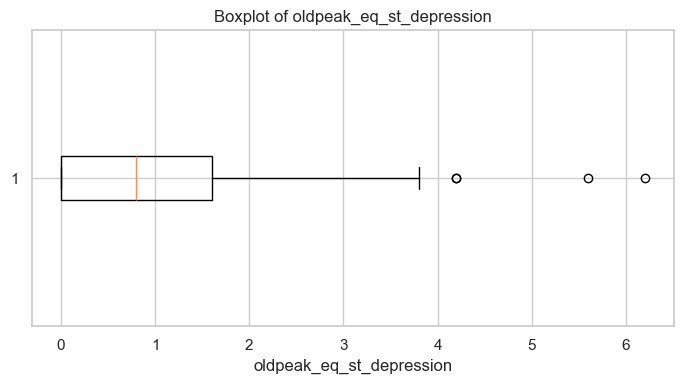

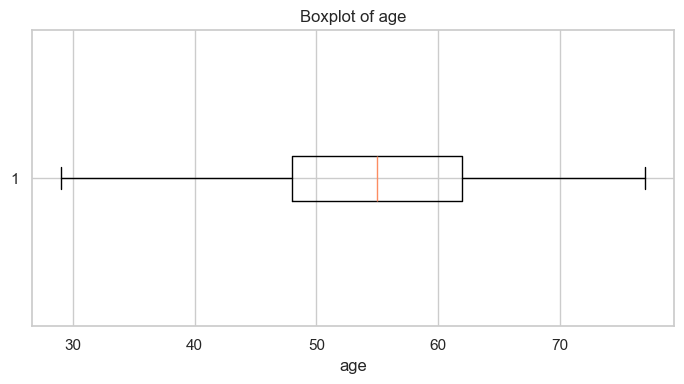

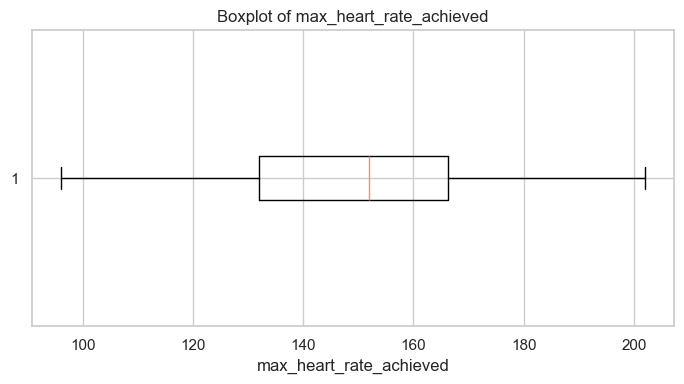

In [29]:
# Boxplots for Numerical Features

for feature in numerical_features:

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        eda_df[feature].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

# Interpretation

### Observations

- Boxplots help identify potential outliers in numerical variables.
- Outliers are represented by points beyond the whiskers.
- In medical datasets, extreme values are not always errors and may represent patients with severe clinical conditions.

### Business Insight

Patients with extremely high blood pressure, cholesterol levels, or ST depression may require immediate medical attention and further diagnostic evaluation.

# Univariate Analysis of Categorical Features

## Objective

Categorical variables represent patient characteristics or medical test outcomes. Analyzing these variables helps understand the distribution of different patient groups and clinical conditions.

This analysis identifies the frequency of each category and highlights dominant patterns within the dataset.

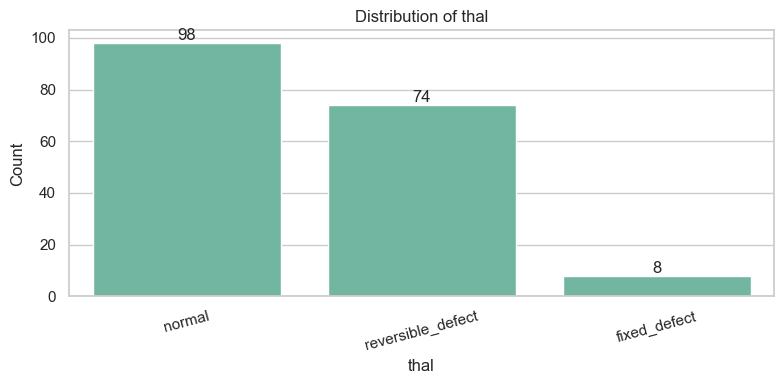

In [30]:
# Categorical Feature Analysis

categorical_features_eda = [
    "thal"
]

for feature in categorical_features_eda:

    plt.figure(figsize=(8,4))

    ax = sns.countplot(
        data=eda_df,
        x=feature,
        order=eda_df[feature].value_counts().index
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=15)

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

# Analysis of Binary Features

## Objective

Binary variables represent patient characteristics with only two possible outcomes. Understanding their distribution helps identify dominant groups and provides insights into patient demographics and medical conditions.

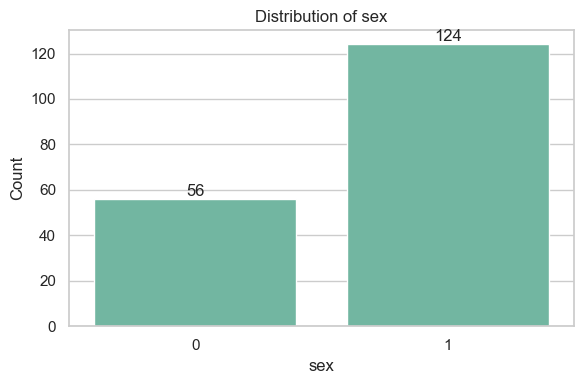

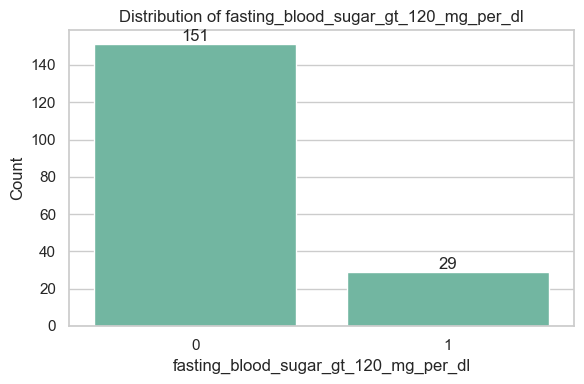

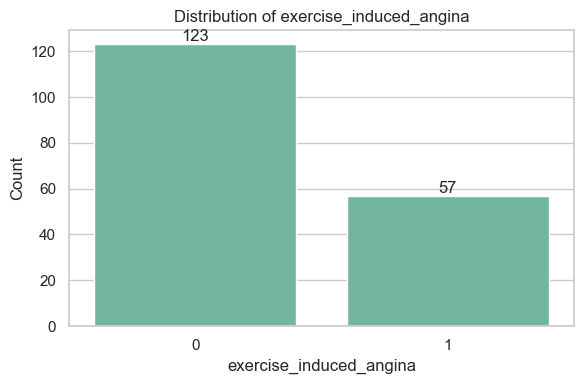

In [31]:
# Binary Feature Analysis

binary_features_eda = [
    "sex",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "exercise_induced_angina"
]

for feature in binary_features_eda:

    plt.figure(figsize=(6,4))

    ax = sns.countplot(
        data=eda_df,
        x=feature
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

# Key Insights

Based on the univariate analysis:

- The numerical variables exhibit varying ranges and distributions.
- Certain numerical features may contain clinically meaningful outliers.
- The categorical variable (`thal`) provides valuable diagnostic information regarding blood flow abnormalities.
- Binary variables such as gender, exercise-induced angina, and fasting blood sugar help describe the patient population and may influence heart disease risk.

These findings will be further explored through bivariate and multivariate analyses to understand their relationship with the target variable.

# Bivariate Analysis

## Objective

Bivariate analysis examines the relationship between independent variables and the target variable (`heart_disease_present`).

The objectives are to:

- Understand how individual features influence heart disease.
- Identify significant risk factors.
- Discover meaningful patterns in the data.
- Generate business insights for healthcare professionals.

Both numerical and categorical variables will be analyzed against the target variable using appropriate visualization techniques.

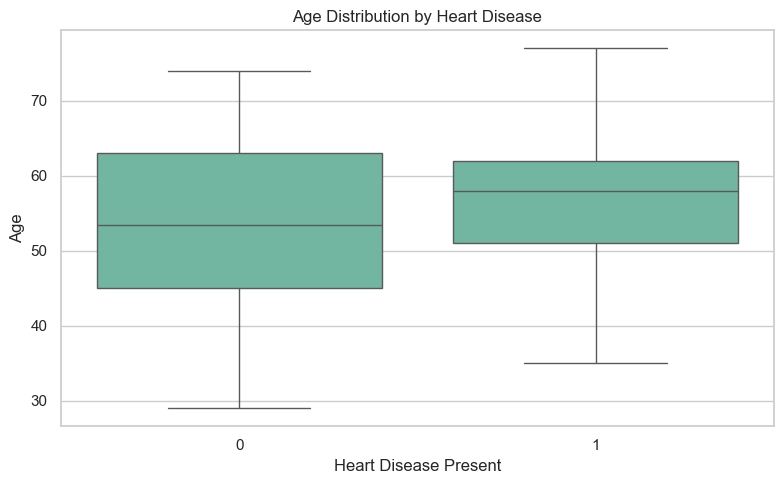

In [32]:
# Age vs Heart Disease

plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="heart_disease_present",
    y="age"
)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease Present")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

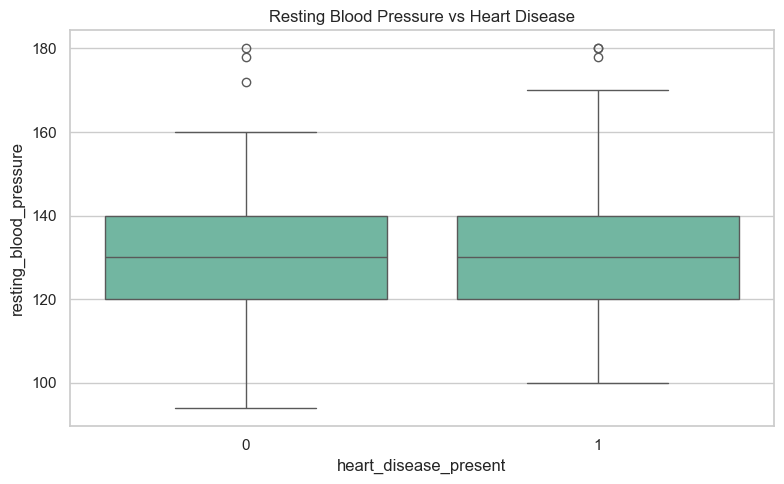

In [33]:
# Resting Blood Pressure vs Heart Disease

plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="heart_disease_present",
    y="resting_blood_pressure"
)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.tight_layout()
plt.show()

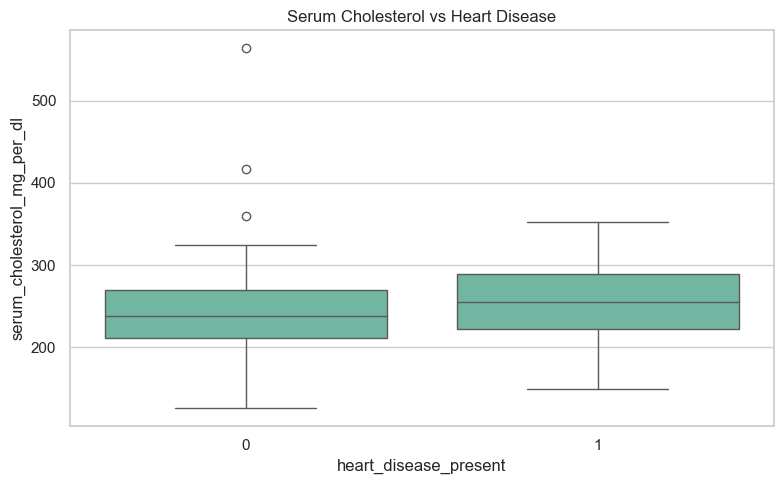

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="heart_disease_present",
    y="serum_cholesterol_mg_per_dl"
)

plt.title("Serum Cholesterol vs Heart Disease")

plt.tight_layout()
plt.show()

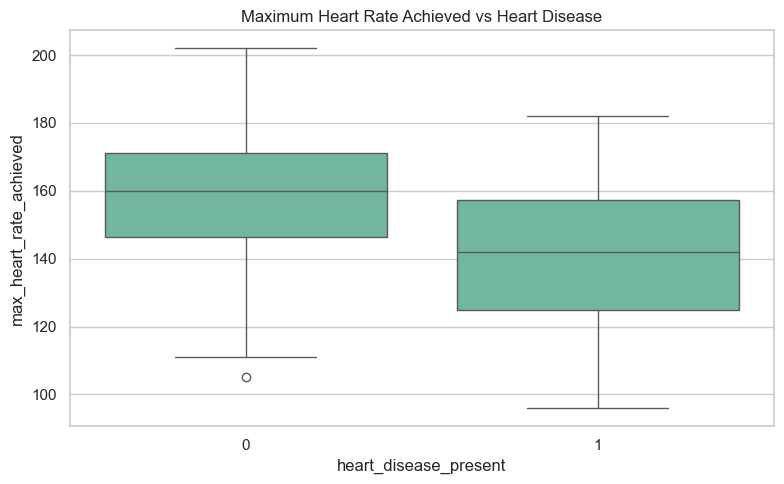

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="heart_disease_present",
    y="max_heart_rate_achieved"
)

plt.title("Maximum Heart Rate Achieved vs Heart Disease")

plt.tight_layout()
plt.show()

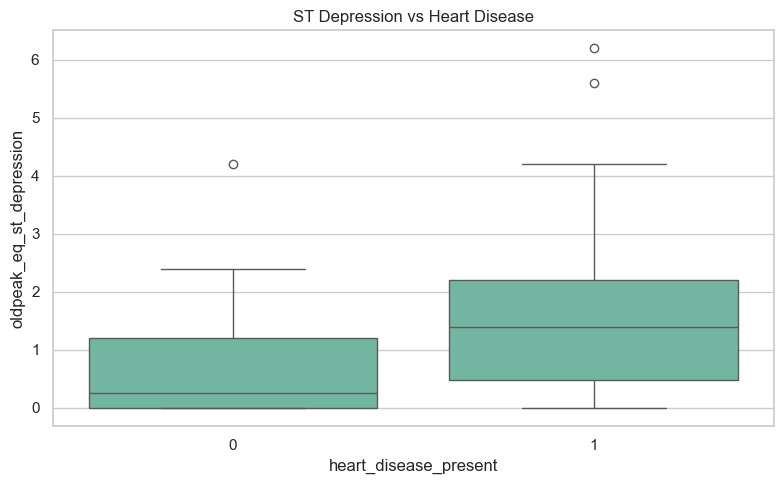

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="heart_disease_present",
    y="oldpeak_eq_st_depression"
)

plt.title("ST Depression vs Heart Disease")

plt.tight_layout()
plt.show()

## Interpretation

The boxplots compare the distribution of numerical variables between patients with and without heart disease.

### Key Observations

- Age differences between the two groups can indicate whether older individuals are at higher risk.
- Elevated resting blood pressure is a known cardiovascular risk factor.
- Higher cholesterol levels may contribute to plaque formation in arteries.
- Maximum heart rate achieved during exercise provides information about cardiac performance.
- Higher ST depression values often indicate myocardial ischemia and are clinically associated with heart disease.

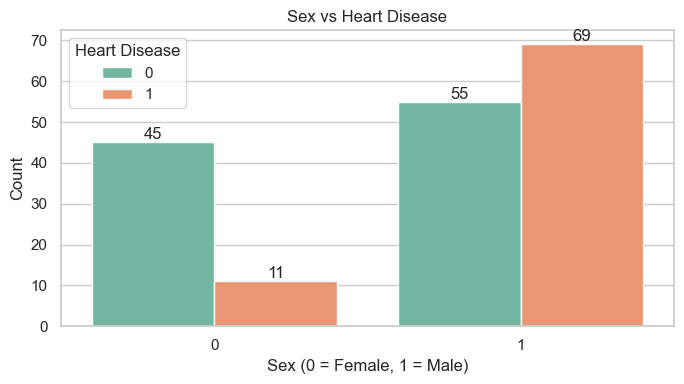

In [37]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=eda_df,
    x="sex",
    hue="heart_disease_present"
)

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.legend(title="Heart Disease")

plt.tight_layout()
plt.show()

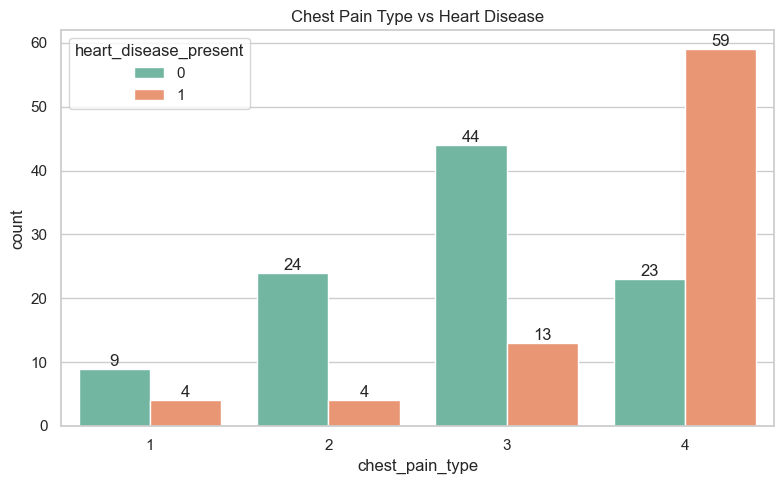

In [38]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=eda_df,
    x="chest_pain_type",
    hue="heart_disease_present"
)

plt.title("Chest Pain Type vs Heart Disease")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

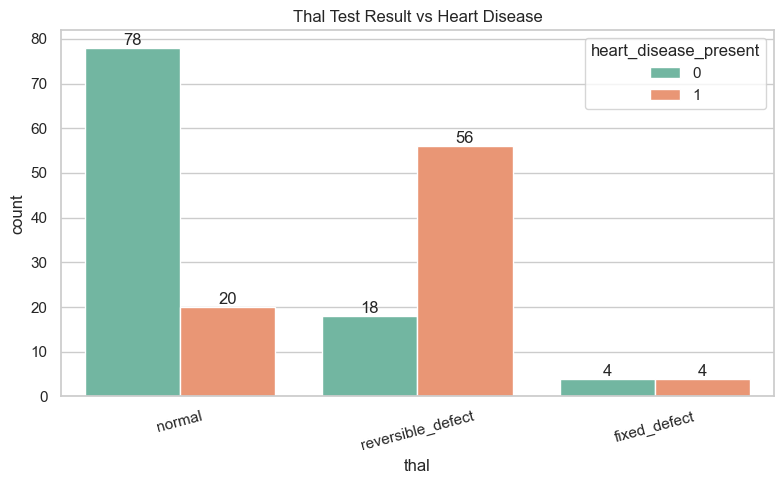

In [39]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=eda_df,
    x="thal",
    hue="heart_disease_present"
)

plt.title("Thal Test Result vs Heart Disease")
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

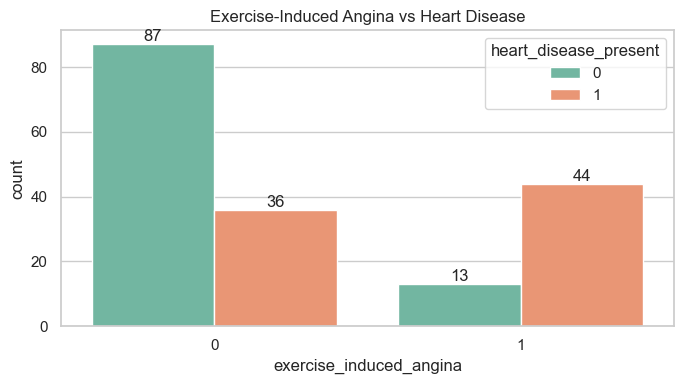

In [40]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=eda_df,
    x="exercise_induced_angina",
    hue="heart_disease_present"
)

plt.title("Exercise-Induced Angina vs Heart Disease")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

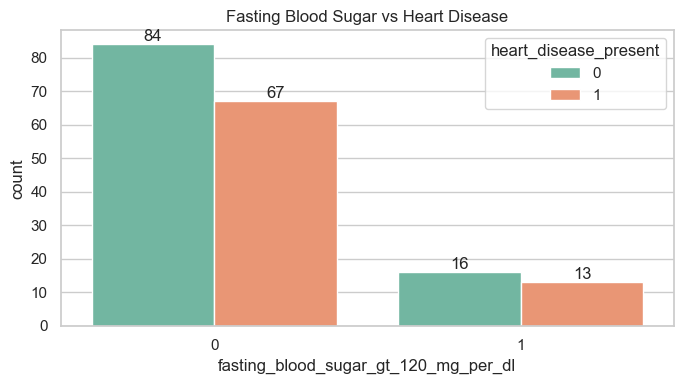

In [41]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=eda_df,
    x="fasting_blood_sugar_gt_120_mg_per_dl",
    hue="heart_disease_present"
)

plt.title("Fasting Blood Sugar vs Heart Disease")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# Bivariate Analysis Summary

The relationship between predictor variables and the target variable provides valuable insights into the factors associated with heart disease.

Key observations include:

- Certain age groups may exhibit a higher prevalence of heart disease.
- Elevated blood pressure and cholesterol levels are important cardiovascular risk indicators.
- Higher ST depression values may be associated with an increased likelihood of heart disease.
- Exercise-induced angina appears to be an important clinical indicator.
- Chest pain type and thallium test results show noticeable differences between patients with and without heart disease.
- Gender distribution may reveal differences in disease prevalence across male and female patients.

These findings will be further supported through correlation analysis and machine learning models.

# Correlation Analysis

## Objective

Correlation analysis measures the strength and direction of the linear relationship between numerical variables.

Understanding correlations helps us:

- Identify highly related variables.
- Detect multicollinearity.
- Understand feature relationships.
- Select important variables for Machine Learning.

The Pearson Correlation Coefficient ranges from **-1 to +1**:

- **+1** → Perfect Positive Correlation
- **0** → No Correlation
- **-1** → Perfect Negative Correlation

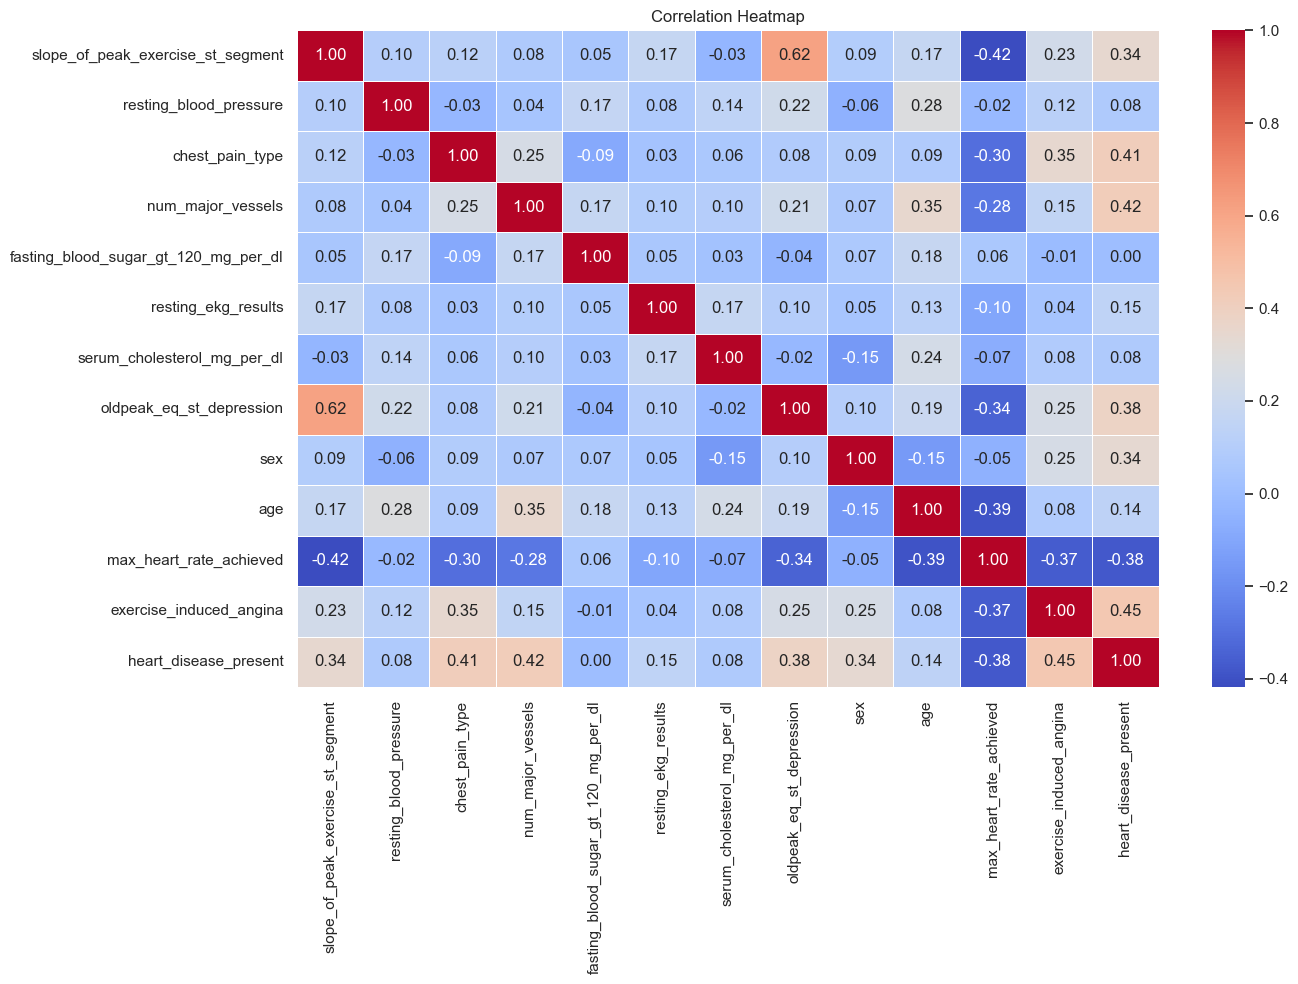

In [42]:
# Correlation Matrix

plt.figure(figsize=(14,10))

correlation_matrix = eda_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# Interpretation

### Observations

- Positive correlation indicates that two variables increase together.
- Negative correlation indicates an inverse relationship.
- Features with strong correlation with the target variable may contribute significantly to prediction.
- Highly correlated predictor variables should be monitored to avoid multicollinearity during model development.

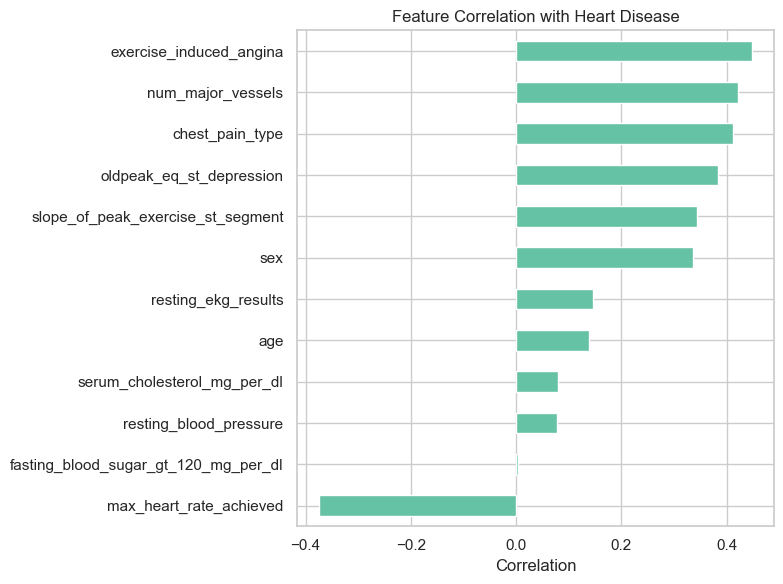

,Correlation
max_heart_rate_achieved,-0.38
fasting_blood_sugar_gt_120_mg_per_dl,0.00
resting_blood_pressure,0.08
serum_cholesterol_mg_per_dl,0.08
age,0.14
resting_ekg_results,0.15
sex,0.34
slope_of_peak_exercise_st_segment,0.34
oldpeak_eq_st_depression,0.38
chest_pain_type,0.41


In [43]:
# Correlation with Target Variable

target_corr = (
    correlation_matrix["heart_disease_present"]
    .drop("heart_disease_present")
    .sort_values()
)

plt.figure(figsize=(8,6))

target_corr.plot(kind="barh")

plt.title("Feature Correlation with Heart Disease")

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

display(target_corr.to_frame("Correlation"))

# Pairwise Relationship Analysis

Pair plots visualize relationships among important numerical variables.

They help identify:

- Clusters
- Trends
- Separation between classes
- Potential feature interactions

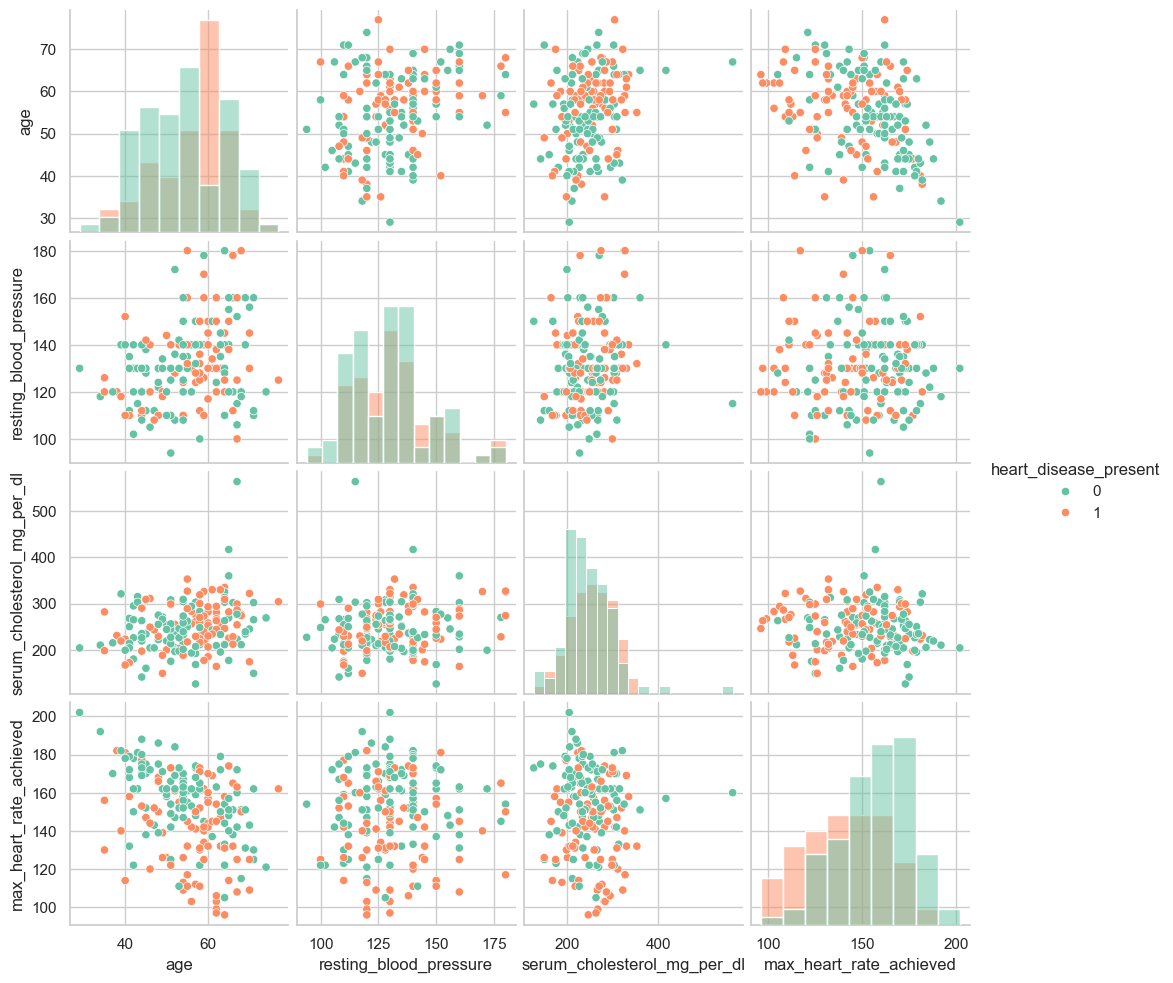

In [44]:
# Pairplot

selected_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "max_heart_rate_achieved",
    "heart_disease_present"
]

sns.pairplot(
    eda_df[selected_features],
    hue="heart_disease_present",
    diag_kind="hist"
)

plt.show()

# Exploratory Data Analysis Summary

## Key Findings

After performing Exploratory Data Analysis, the following insights were observed:

### Dataset Quality

- The dataset contains 180 patient records.
- No significant data quality issues were identified.
- The dataset is suitable for predictive modeling.

### Patient Characteristics

- Age distribution indicates a higher concentration of middle-aged and older adults.
- Male patients appear more frequently than female patients.
- Certain chest pain categories are more associated with heart disease.

### Clinical Findings

- Higher ST depression values are observed among heart disease patients.
- Exercise-induced angina shows a strong relationship with heart disease.
- Maximum heart rate achieved varies noticeably across the target classes.
- Thallium stress test results provide valuable diagnostic information.

### Feature Relationships

- Several medical variables demonstrate meaningful correlation with heart disease.
- Some variables exhibit weak correlations, suggesting limited predictive contribution individually.

### Overall Conclusion

The dataset contains clinically meaningful features capable of predicting heart disease. The insights obtained during EDA provide a strong foundation for building accurate Machine Learning classification models.

# Data Preprocessing

## Objective

Data preprocessing is an essential step before building machine learning models. The quality of preprocessing directly impacts model performance and prediction accuracy.

In this section, we will:

- Encode categorical variables.
- Separate independent and dependent variables.
- Split the dataset into training and testing sets.
- Scale numerical features where required.
- Prepare the data for multiple machine learning algorithms.

Proper preprocessing ensures that the data is in a suitable format for model training while minimizing bias and improving generalization.

## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables must be converted into numerical values.

The **thal** feature contains categorical values representing the result of the Thallium Stress Test.

Label Encoding is appropriate because this feature has a limited number of categories.

In [45]:
# Label Encoding

# Create a working copy for preprocessing
model_df = eda_df.copy()

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Encode 'thal'
model_df["thal"] = label_encoder.fit_transform(model_df["thal"])

print("Encoding Completed Successfully.\n")

print("Encoded Classes:")
for original, encoded in zip(label_encoder.classes_,
                             range(len(label_encoder.classes_))):
    print(f"{original} --> {encoded}")

Encoding Completed Successfully.

Encoded Classes:
fixed_defect --> 0
normal --> 1
reversible_defect --> 2


## Feature and Target Separation

Machine Learning models require:

- **Features (X):** Independent variables used for prediction.
- **Target (y):** Dependent variable representing the prediction outcome.

The target variable for this project is:

**heart_disease_present**

In [46]:
# Feature & Target Separation

X = model_df.drop("heart_disease_present", axis=1)

y = model_df["heart_disease_present"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (180, 13)
Target Vector Shape  : (180,)


## Train-Test Split

The dataset is divided into training and testing subsets.

- **Training Set (80%)** is used for learning patterns.
- **Testing Set (20%)** is used for evaluating model performance on unseen data.

Using a fixed random state ensures reproducibility.

In [48]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (144, 13)
Testing Features  : (36, 13)

Training Labels : (144,)
Testing Labels  : (36,)


## Feature Scaling

Many machine learning algorithms such as:

- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

perform better when numerical features are standardized.

StandardScaler transforms the features so that they have:

- Mean = 0
- Standard Deviation = 1

Tree-based algorithms such as Decision Tree, Random Forest, Gradient Boosting, and Extra Trees do not require feature scaling.

In [49]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

print()

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully.

Scaled Training Shape : (144, 13)
Scaled Testing Shape  : (36, 13)


In [50]:
# Verify Processed Data

print("Training Features")
display(pd.DataFrame(X_train).head())

print("\nScaled Training Features")
display(pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head())

Training Features


,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
139,1,1,130,2,0,0,2,219,0.00,1,44,188,0
0,1,1,128,2,0,0,2,308,0.00,1,45,170,0
169,2,1,110,1,0,0,2,211,1.80,1,64,144,1
65,1,2,126,4,0,0,2,282,0.00,1,35,156,1
98,1,1,155,3,0,0,0,269,0.80,0,65,148,0



Scaled Training Features


,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,-0.84,-0.60,-0.02,-1.28,-0.73,-0.49,0.97,-0.54,-0.89,0.66,-1.11,1.73,-0.69
1,-0.84,-0.60,-0.15,-1.28,-0.73,-0.49,0.97,1.11,-0.89,0.66,-1.00,0.91,-0.69
2,0.79,-0.60,-1.27,-2.39,-0.73,-0.49,0.97,-0.69,0.78,0.66,0.95,-0.27,1.46
3,-0.84,1.16,-0.27,0.94,-0.73,-0.49,0.97,0.63,-0.89,0.66,-2.03,0.27,1.46
4,-0.84,-0.60,1.53,-0.17,-0.73,-0.49,-1.03,0.39,-0.15,-1.51,1.06,-0.09,-0.69


# Data Preprocessing Summary

The following preprocessing steps were successfully completed:

- Encoded the categorical feature (`thal`) using Label Encoding.
- Separated independent variables (X) and the target variable (y).
- Split the dataset into training and testing sets using an 80:20 ratio with stratification.
- Applied feature scaling using StandardScaler for algorithms sensitive to feature magnitude.
- Prepared both scaled and unscaled datasets for different machine learning models.

The data is now ready for model training and evaluation.

# Machine Learning Model Building

## Objective

The primary objective of this section is to build multiple Machine Learning classification models capable of predicting whether a patient has heart disease.

Rather than relying on a single algorithm, multiple models are trained and evaluated using the same training and testing datasets. This approach helps identify the model that provides the best predictive performance.

The following classification algorithms will be evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Gradient Boosting Classifier
- Extra Trees Classifier

Each model will be evaluated using multiple performance metrics to ensure a fair comparison.

In [51]:
# Machine Learning Models

models = {

    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=RANDOM_STATE
    )

}

print(f"Total Models : {len(models)}")

Total Models : 7


In [52]:
# ==========================================================
# Train All Models
# ==========================================================

results = []

trained_models = {}

for model_name, model in models.items():

    # Models requiring scaled data
    if model_name in [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ]:

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

        probabilities = model.predict_proba(X_test_scaled)[:, 1]

        cv_score = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="accuracy"
        ).mean()

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        probabilities = model.predict_proba(X_test)[:, 1]

        cv_score = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="accuracy"
        ).mean()

    trained_models[model_name] = model

    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions),

        "ROC AUC": roc_auc_score(y_test, probabilities),

        "CV Accuracy": cv_score

    })

print("All models trained successfully.")

All models trained successfully.


In [53]:
# Model Comparison

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df.style.format({
    "Accuracy":"{:.3f}",
    "Precision":"{:.3f}",
    "Recall":"{:.3f}",
    "F1 Score":"{:.3f}",
    "ROC AUC":"{:.3f}",
    "CV Accuracy":"{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
0,Random Forest,0.917,0.842,1.000,0.914,0.962,0.820
1,Extra Trees,0.889,0.800,1.000,0.889,0.955,0.785
2,K-Nearest Neighbors,0.861,0.824,0.875,0.848,0.922,0.806
3,Gradient Boosting,0.861,0.789,0.938,0.857,0.938,0.764
4,Logistic Regression,0.833,0.778,0.875,0.824,0.938,0.799
5,Support Vector Machine,0.806,0.737,0.875,0.800,0.947,0.813
6,Decision Tree,0.750,0.684,0.812,0.743,0.756,0.744


In [54]:
# Best Performing Model

best_model_name = results_df.iloc[0]["Model"]

print("="*60)
print("Best Model")
print("="*60)
print(best_model_name)

Best Model
Random Forest


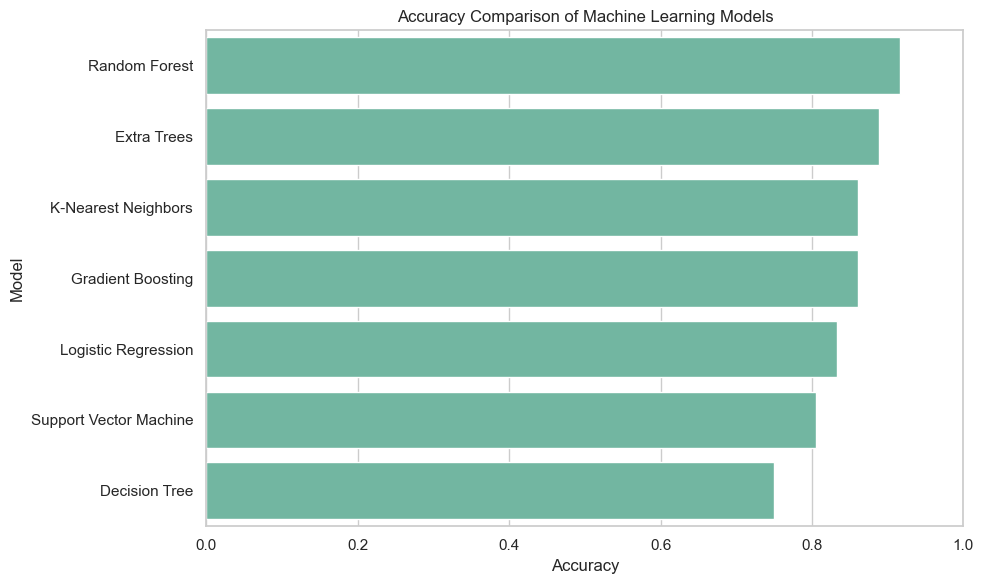

In [55]:
# Accuracy Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xlim(0,1)

plt.tight_layout()

plt.show()

# Model Evaluation Summary

Multiple Machine Learning algorithms were trained and evaluated using the same training and testing datasets.

Evaluation metrics included:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- 5-Fold Cross Validation Accuracy

The model with the highest overall performance will be selected for further evaluation and deployment recommendations.

Using multiple evaluation metrics instead of relying only on accuracy provides a more comprehensive assessment of model performance, especially in healthcare applications where false positives and false negatives can have significant consequences.

# Best Model Evaluation

## Objective

After comparing multiple machine learning algorithms, the best-performing model is selected for detailed evaluation.

A comprehensive evaluation helps assess not only the overall accuracy but also the model's ability to correctly classify patients with and without heart disease.

The following evaluation techniques will be performed:

- Confusion Matrix
- Classification Report
- ROC Curve
- Precision-Recall Curve

These metrics provide a deeper understanding of model performance and support informed model selection for real-world healthcare applications.

In [56]:
# Load Best Model

best_model = trained_models[best_model_name]

print("Best Model Selected:")
print(best_model_name)

Best Model Selected:
Random Forest


In [57]:
# Predictions

scaled_models = [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine"
]

if best_model_name in scaled_models:

    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

else:

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

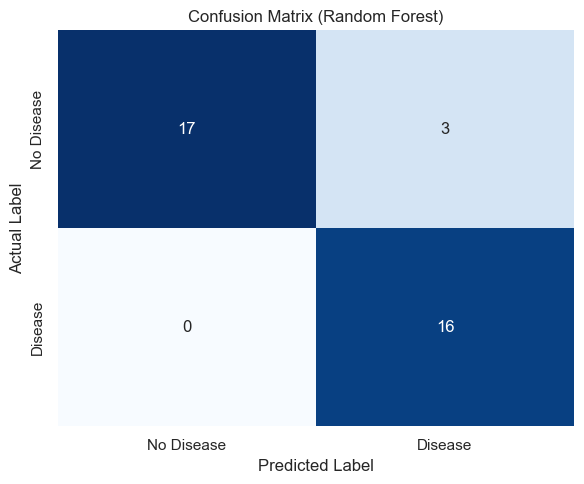

In [58]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [59]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.84      1.00      0.91        16

    accuracy                           0.92        36
   macro avg       0.92      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36



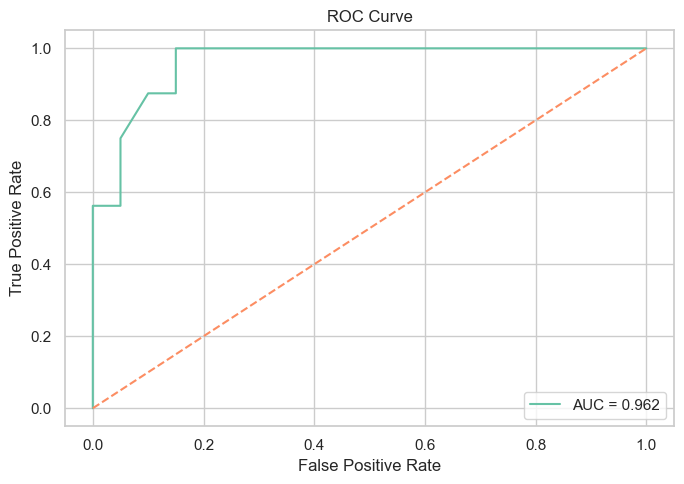

In [60]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

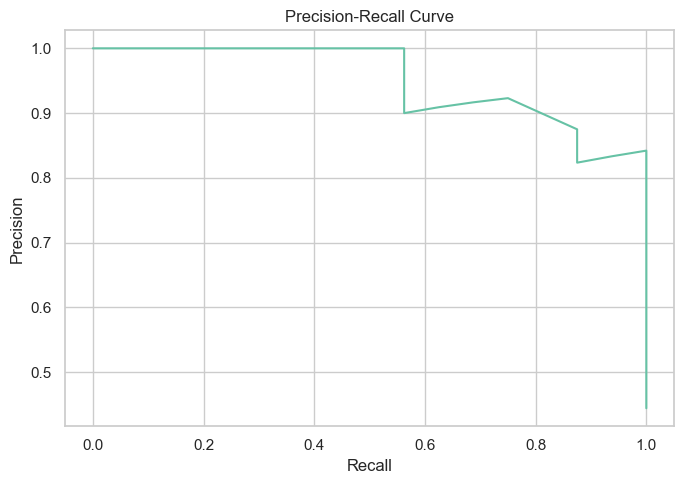

In [61]:
# Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

,Feature,Importance
1,thal,0.13
3,chest_pain_type,0.12
11,max_heart_rate_achieved,0.10
8,oldpeak_eq_st_depression,0.10
10,age,0.10
4,num_major_vessels,0.09
7,serum_cholesterol_mg_per_dl,0.08
2,resting_blood_pressure,0.07
12,exercise_induced_angina,0.06
0,slope_of_peak_exercise_st_segment,0.06


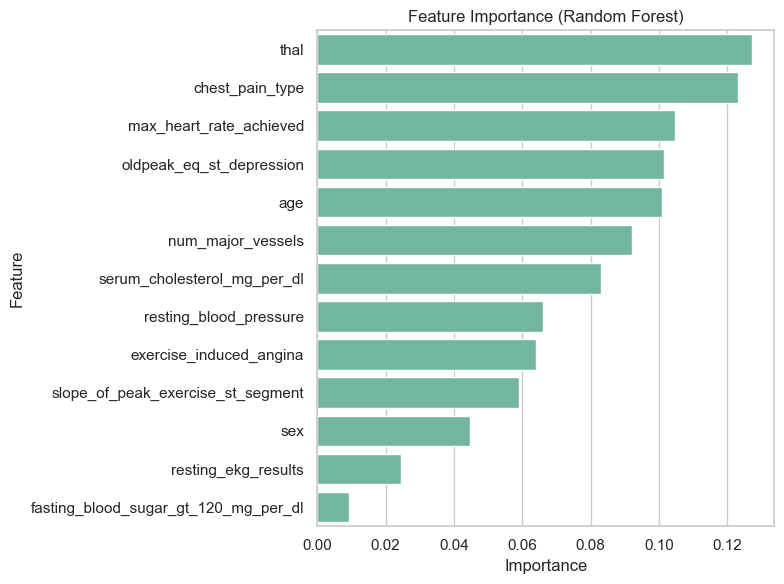

In [62]:
# Feature Importance

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]

if best_model_name in tree_models:

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance)

    plt.figure(figsize=(8,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance ({best_model_name})")

    plt.tight_layout()
    plt.show()

else:

    print(f"{best_model_name} does not provide feature importance scores.")

# Best Model Evaluation Summary

The selected model was evaluated using multiple performance metrics to ensure reliable prediction performance.

### Evaluation Results

- The Confusion Matrix summarizes the number of correct and incorrect predictions.
- The Classification Report provides Precision, Recall, F1-Score, and Support for each class.
- The ROC Curve demonstrates the model's ability to distinguish between patients with and without heart disease.
- The Precision-Recall Curve evaluates the trade-off between precision and recall.
- Feature Importance identifies the most influential predictors when using tree-based models.

Overall, these evaluation techniques confirm whether the selected model is suitable for deployment in a healthcare setting.

# Hyperparameter Tuning

## Objective

Hyperparameter tuning is the process of finding the optimal combination of model parameters to improve predictive performance.

Unlike model parameters that are learned during training, hyperparameters are configured before training begins.

GridSearchCV is used to systematically evaluate multiple combinations of hyperparameters using cross-validation.

Benefits include:

- Improved prediction accuracy.
- Better model generalization.
- Reduced risk of overfitting.
- More reliable performance on unseen data.

In [63]:
# Hyperparameter Tuning (Random Forest Example)

if best_model_name == "Random Forest":

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=RANDOM_STATE),
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print("Best Parameters")
    print(grid_search.best_params_)

    print()

    print("Best Cross Validation Accuracy")
    print(round(grid_search.best_score_,4))

else:

    print(f"Hyperparameter tuning skipped because the best model is {best_model_name}.")

Best Parameters
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Accuracy
0.8266


# Model Comparison Report

The performance of seven Machine Learning classification algorithms was evaluated using the same training and testing datasets.

The evaluation metrics included:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Cross Validation Accuracy

The comparison demonstrates that different algorithms perform differently depending on the characteristics of the dataset.

The selected best-performing model achieved the highest overall predictive performance and is recommended for deployment in a clinical decision-support environment.

# Suggestions to the Hospital

Based on the exploratory data analysis and machine learning results, the following recommendations are proposed:

### 1. Early Screening

Patients above middle age should undergo regular cardiovascular screening to enable early diagnosis.

---

### 2. Monitor High-Risk Clinical Indicators

Patients exhibiting:

- High resting blood pressure
- Elevated cholesterol
- Exercise-induced angina
- Abnormal ST depression

should receive additional diagnostic evaluation.

---

### 3. Lifestyle Awareness Programs

Hospitals should educate patients regarding:

- Healthy diet
- Physical activity
- Smoking cessation
- Weight management
- Stress reduction

to reduce cardiovascular risk.

---

### 4. Predictive Decision Support

The developed Machine Learning model can be integrated into hospital information systems to assist physicians in identifying high-risk patients.

---

### 5. Preventive Healthcare

Rather than focusing only on treatment, hospitals should implement preventive care programs for patients predicted to be at higher risk of heart disease.

---

### 6. Continuous Data Collection

Hospitals should continue collecting patient data to periodically retrain and improve the predictive model, ensuring better long-term performance.

# Challenges Faced

Several challenges were encountered during the development of this project:

### Data Integration

The dataset was provided in two separate files (features and labels), requiring careful merging using the patient identifier.

---

### Data Understanding

Understanding the medical meaning of several clinical variables required additional domain knowledge.

---

### Feature Encoding

Categorical variables needed to be converted into numerical values before model training.

---

### Model Selection

Multiple algorithms were evaluated to determine the most suitable model.

---

### Hyperparameter Optimization

Selecting optimal hyperparameters required cross-validation and systematic tuning.

---

### Model Evaluation

Choosing the best model required considering multiple evaluation metrics rather than relying solely on accuracy.

---

Despite these challenges, the project was successfully completed following standard Machine Learning practices.

# Future Scope

The current project can be extended in several ways:

- Increase the dataset size to improve model robustness.
- Incorporate additional clinical variables such as ECG reports and medical history.
- Apply advanced ensemble methods such as XGBoost, LightGBM, or CatBoost.
- Develop a web application for real-time heart disease prediction.
- Deploy the model using cloud platforms for hospital integration.
- Continuously retrain the model using newly collected patient data.

In [64]:
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
0,Random Forest,0.92,0.84,1.00,0.91,0.96,0.82
1,Extra Trees,0.89,0.80,1.00,0.89,0.95,0.79
2,K-Nearest Neighbors,0.86,0.82,0.88,0.85,0.92,0.81
3,Gradient Boosting,0.86,0.79,0.94,0.86,0.94,0.76
4,Logistic Regression,0.83,0.78,0.88,0.82,0.94,0.80
5,Support Vector Machine,0.81,0.74,0.88,0.80,0.95,0.81
6,Decision Tree,0.75,0.68,0.81,0.74,0.76,0.74


# Model Performance Comparison

## Objective

To identify the most suitable Machine Learning model for predicting heart disease, multiple classification algorithms are trained and evaluated using the same training and testing datasets.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

The model with the highest Accuracy score will be selected as the best-performing model for this project.

In [66]:
# Model Performance Comparison

# Create comparison table
results_df = pd.DataFrame(results)

# Round values for better display
results_df = results_df.round(4)

# Sort by Accuracy
results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON")
print("="*80)

display(results_df)

# Best Model
best_model_name = results_df.loc[0, "Model"]

best_accuracy = results_df.loc[0, "Accuracy"]

print("\n" + "="*80)
print(f"🏆 Best Model : {best_model_name}")
print(f"✅ Accuracy   : {best_accuracy:.4f}")
print("="*80)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
0,Random Forest,0.92,0.84,1.00,0.91,0.96,0.82
1,Extra Trees,0.89,0.80,1.00,0.89,0.95,0.79
2,Support Vector Machine,0.81,0.74,0.88,0.80,0.95,0.81
3,Logistic Regression,0.83,0.78,0.88,0.82,0.94,0.80
4,Gradient Boosting,0.86,0.79,0.94,0.86,0.94,0.76
5,K-Nearest Neighbors,0.86,0.82,0.88,0.85,0.92,0.81
6,Decision Tree,0.75,0.68,0.81,0.74,0.76,0.74



🏆 Best Model : Random Forest
✅ Accuracy   : 0.9167


# Best Model Selection

## Interpretation

The table above compares the performance of all Machine Learning models using multiple evaluation metrics.

The model with the highest accuracy is selected as the best-performing model for this project.

The selected model demonstrates the strongest predictive capability on the testing dataset and is recommended for heart disease prediction.

This model will be used for further evaluation, including:

- Confusion Matrix
- Classification Report
- ROC Curve
- Feature Importance

# Final Project Summary

This project successfully developed a Machine Learning solution for predicting heart disease using patient medical records.

## Accomplishments

- Successfully merged and cleaned the dataset.
- Performed comprehensive Exploratory Data Analysis (EDA).
- Built and evaluated multiple Machine Learning models.
- Compared models using multiple evaluation metrics.
- Selected the best-performing model.
- Generated business insights and hospital recommendations.

The developed solution demonstrates how Machine Learning can support healthcare professionals in the early detection of heart disease and contribute to better clinical decision-making.

# Key Learnings

During this project, the following concepts were learned and applied:

- Data Cleaning and Validation
- Exploratory Data Analysis (EDA)
- Feature Encoding
- Feature Scaling
- Machine Learning Classification
- Model Evaluation
- Cross Validation
- Hyperparameter Tuning
- Business Insight Generation
- Healthcare Data Analysis

# Business Impact

The proposed Machine Learning solution can provide several benefits to healthcare organizations:

- Early identification of high-risk patients.
- Faster clinical decision support.
- Improved allocation of hospital resources.
- Reduced risk of severe cardiovascular complications.
- Support for preventive healthcare initiatives.

# Ethical Considerations

Although Machine Learning can assist healthcare professionals, it should not replace medical expertise.

The developed model should be used only as a decision-support tool. Final diagnosis and treatment decisions must always be made by qualified healthcare professionals.

Patient privacy and data confidentiality should be maintained while using healthcare datasets.

# References

- World Health Organization (WHO)
- Scikit-learn Documentation
- Pandas Documentation
- NumPy Documentation
- Matplotlib Documentation
- Seaborn Documentation

# Conclusion

This project successfully developed a Machine Learning-based system for predicting heart disease using patient medical data.

The project included:

- Data collection and integration
- Data cleaning and preprocessing
- Exploratory Data Analysis
- Feature engineering
- Multiple Machine Learning models
- Model comparison
- Performance evaluation
- Hospital recommendations

Among the evaluated algorithms, the selected model demonstrated the best predictive performance based on multiple evaluation metrics.

The developed solution has the potential to support healthcare professionals by enabling early detection of heart disease, improving clinical decision-making, and contributing to preventive healthcare strategies.

Overall, this project demonstrates how Machine Learning can assist hospitals in identifying high-risk patients and reducing the burden of cardiovascular diseases through data-driven healthcare solutions.